In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import scipy.stats as stats

# Set visual style for the final paper
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12, 'figure.dpi': 150})

def load_algorithm_data(folder_path, algo_name):
    path = Path(folder_path)
    # This specifically targets ONLY .csv files, ignoring .sol or .vrp files!
    all_files = list(path.glob("*.csv")) 
    
    if not all_files:
        print(f"[Warning] No CSVs found in {folder_path}!")
        return pd.DataFrame()
        
    df_list = []
    for f in all_files:
        df = pd.read_csv(f)
        df['Algorithm'] = algo_name
        df_list.append(df)
        
    final_df = pd.concat(df_list, ignore_index=True)
    print(f"Loaded {len(final_df)} runs for {algo_name}.")
    return final_df

# --- Load the Champions ---
# Pointing directly to the winning sub-folders for a fair comparison
df_ga = load_algorithm_data("experiments/ga/feasibility_archive", "GA (Crowding)")
df_aco = load_algorithm_data("experiments/aco/feasibility_archive", "ACO")

# Change 'sc' to 'complete_cluster' if that was the PSO team's winning variant!
df_pso = load_algorithm_data("experiments/pso/sc", "PSO") 

# Combine into one massive global dataset
df_global = pd.concat([df_ga, df_aco, df_pso], ignore_index=True)

# Display a preview
display(df_global.head())

Loaded 455 runs for GA (Crowding).
Loaded 1820 runs for ACO.
Loaded 1820 runs for PSO.


,run,mean_fitness,std_fitness,mean_jaccard_distance,n_evaluations,n_generations,experiment_id,tiempo,Algorithm
0,1,40193.233653,606.920970,0.857877,6000,100,X-n101-k25,8.847728,GA (Crowding)
1,0,41182.436991,503.201672,0.814906,6000,100,X-n101-k25,5.494893,GA (Crowding)
2,2,39665.810684,903.152615,0.497159,6000,100,X-n101-k25,6.417424,GA (Crowding)
3,3,40790.088479,455.284617,0.588467,6000,100,X-n101-k25,9.106700,GA (Crowding)
4,4,40281.398708,350.744331,0.807486,6000,100,X-n101-k25,16.976037,GA (Crowding)


In [2]:
# Group by Algorithm and calculate Mean & Std for the crucial metrics
global_summary = df_global.groupby('Algorithm').agg(
    Avg_Cost=('mean_fitness', 'mean'),
    Cost_Std=('mean_fitness', 'std'),
    Avg_Diversity=('mean_jaccard_distance', 'mean'),
    Avg_Time=('tiempo', 'mean')
).reset_index()

# Format the results cleanly
global_summary['Avg_Cost'] = global_summary['Avg_Cost'].round(2)
global_summary['Cost_Std'] = global_summary['Cost_Std'].round(2)
global_summary['Avg_Diversity'] = (global_summary['Avg_Diversity'] * 100).round(2).astype(str) + '%'
global_summary['Avg_Time'] = global_summary['Avg_Time'].round(2).astype(str) + 's'

print("=== GLOBAL PERFORMANCE SUMMARY ===")
display(global_summary)

=== GLOBAL PERFORMANCE SUMMARY ===


,Algorithm,Avg_Cost,Cost_Std,Avg_Diversity,Avg_Time
0,ACO,65816.90,66874.09,65.37%,323.8s
1,GA (Crowding),136598.74,358849.18,82.86%,16.03s
2,PSO,112095.67,112399.83,90.61%,101.19s


/tmp/ipykernel_91720/2344950795.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_global, x='Algorithm', y='mean_fitness', ax=axes[0], palette=palette)
/tmp/ipykernel_91720/2344950795.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_global, x='Algorithm', y='mean_jaccard_distance', ax=axes[1], palette=palette)


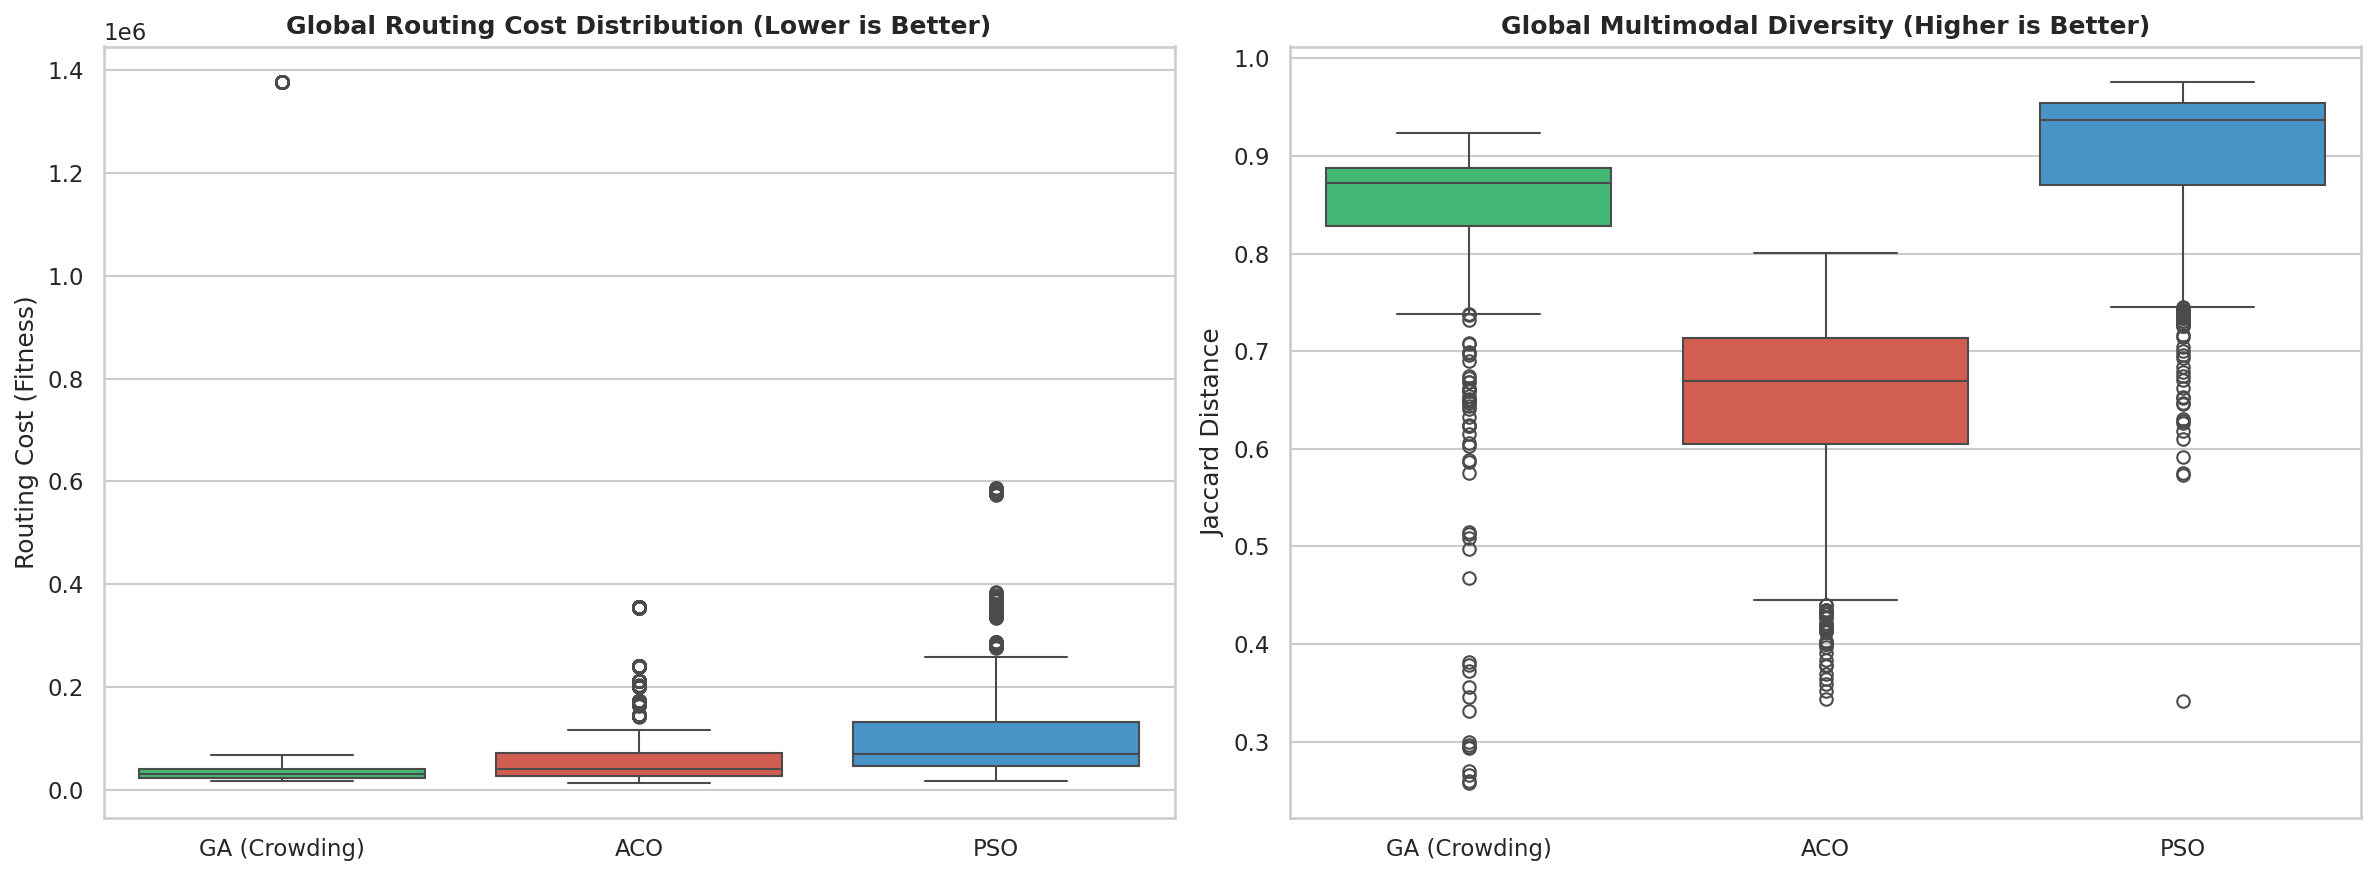

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
palette = {"GA (Crowding)": "#2ecc71", "ACO": "#e74c3c", "PSO": "#3498db"}

# --- Plot 1: Routing Cost (Lower is Better) ---
sns.boxplot(data=df_global, x='Algorithm', y='mean_fitness', ax=axes[0], palette=palette)
axes[0].set_title("Global Routing Cost Distribution (Lower is Better)", fontweight='bold')
axes[0].set_ylabel("Routing Cost (Fitness)")
axes[0].set_xlabel("")

# --- Plot 2: Structural Diversity (Higher is Better) ---
sns.boxplot(data=df_global, x='Algorithm', y='mean_jaccard_distance', ax=axes[1], palette=palette)
axes[1].set_title("Global Multimodal Diversity (Higher is Better)", fontweight='bold')
axes[1].set_ylabel("Jaccard Distance")
axes[1].set_xlabel("")

plt.tight_layout()
plt.savefig("experiments/global_comparison_boxplots_cost_diversity.png")
plt.show()

/tmp/ipykernel_91720/3607429432.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_global, x='Algorithm', y='std_fitness', ax=axes[0], palette=palette)
/tmp/ipykernel_91720/3607429432.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_global, x='Algorithm', y='tiempo', ax=axes[1], palette=palette)


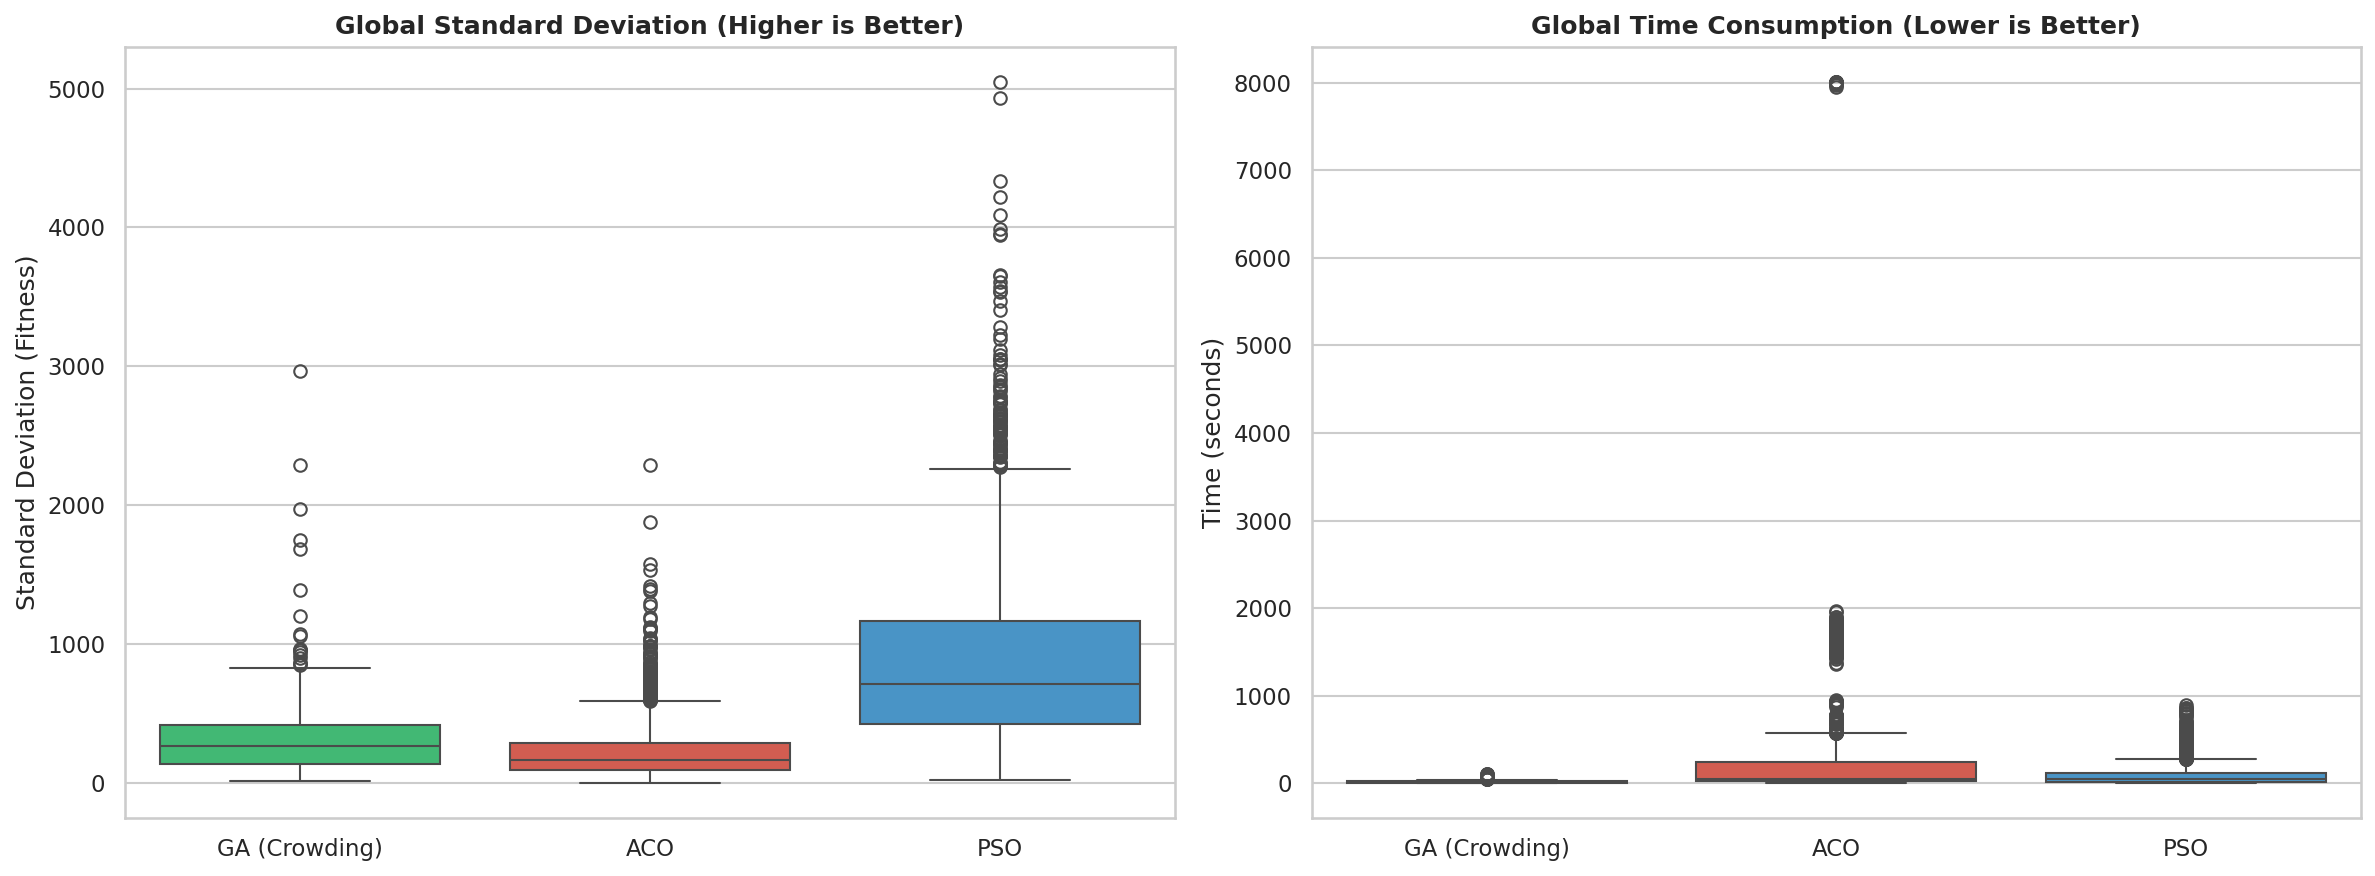

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
palette = {"GA (Crowding)": "#2ecc71", "ACO": "#e74c3c", "PSO": "#3498db"}

# --- Plot 3: Standard Deviation (Lower is Better) ---
sns.boxplot(data=df_global, x='Algorithm', y='std_fitness', ax=axes[0], palette=palette)
axes[0].set_title("Global Standard Deviation (Higher is Better)", fontweight='bold')
axes[0].set_ylabel("Standard Deviation (Fitness)")
axes[0].set_xlabel("")

# --- Plot 4: Time Consumption (Higher is Better) ---
sns.boxplot(data=df_global, x='Algorithm', y='tiempo', ax=axes[1], palette=palette)
axes[1].set_title("Global Time Consumption (Lower is Better)", fontweight='bold')
axes[1].set_ylabel("Time (seconds)")
axes[1].set_xlabel("")

plt.tight_layout()
plt.savefig("experiments/global_comparison_boxplots_std_time.png")
plt.show()

NOTE: ACO is pre-configured with a static number of generations/evaluations


/tmp/ipykernel_91720/2576134738.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_global, x='Algorithm', y='n_evaluations', ax=axes[0], palette=palette)
/tmp/ipykernel_91720/2576134738.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_global, x='Algorithm', y='n_generations', ax=axes[1], palette=palette)


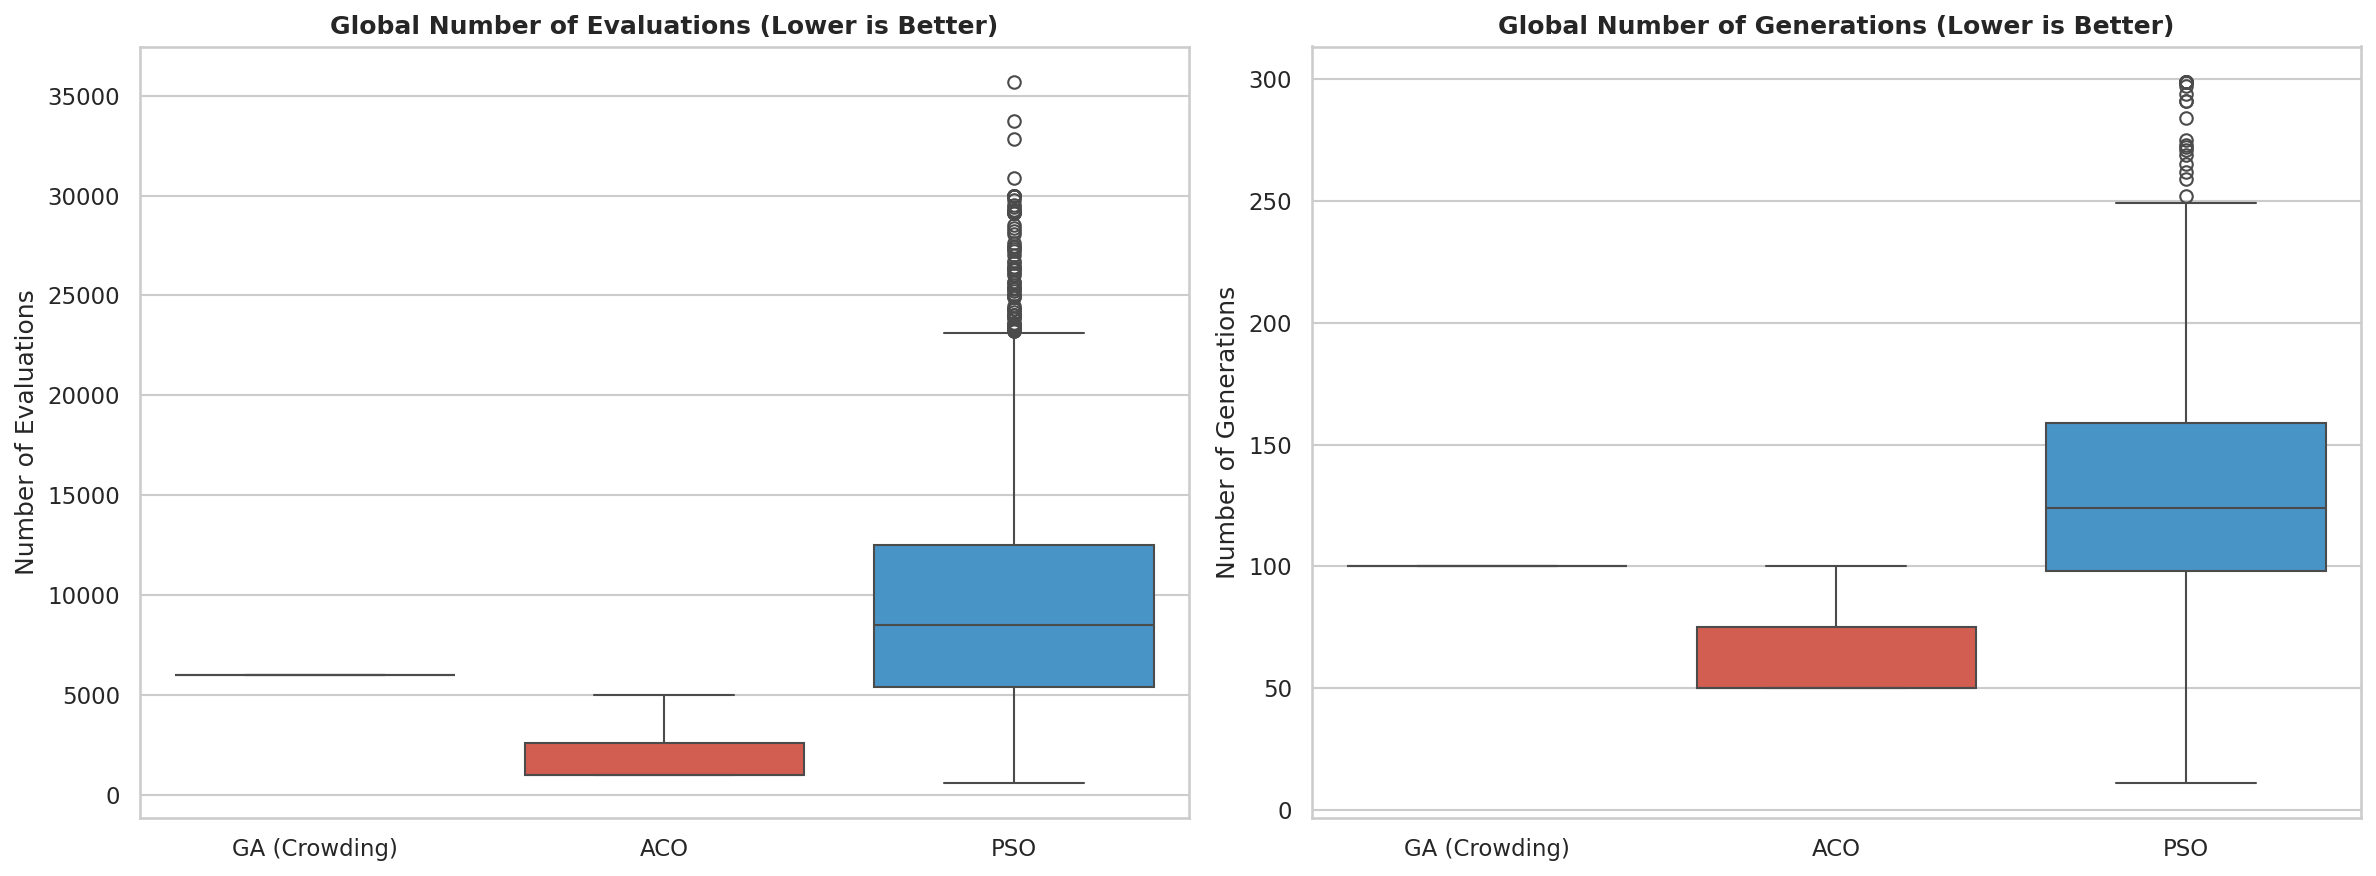

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
palette = {"GA (Crowding)": "#2ecc71", "ACO": "#e74c3c", "PSO": "#3498db"}

print('NOTE: ACO is pre-configured with a static number of generations/evaluations')

# --- Plot 5: Number of Evaluations (Lower is Better) ---
sns.boxplot(data=df_global, x='Algorithm', y='n_evaluations', ax=axes[0], palette=palette)
axes[0].set_title("Global Number of Evaluations (Lower is Better)", fontweight='bold')
axes[0].set_ylabel("Number of Evaluations")
axes[0].set_xlabel("")

# --- Plot 6: Number of Generations (Higher is Better) ---
sns.boxplot(data=df_global, x='Algorithm', y='n_generations', ax=axes[1], palette=palette)
axes[1].set_title("Global Number of Generations (Lower is Better)", fontweight='bold')
axes[1].set_ylabel("Number of Generations")
axes[1].set_xlabel("")

plt.tight_layout()
plt.savefig("experiments/global_comparison_boxplots_n_evaluations_generations.png")
plt.show()